# Setup

In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Data

In [3]:
version = "2026-05-15-15h"
df_filepath = f"/gpfs01/berens/data/data/Eyewire2/manuscript/df_all_neurons_{version}.pickle"
df = pd.read_pickle(df_filepath)
print(df.shape)

(59003, 400)


In [4]:
assert not df.columns.duplicated().any()

# Labels and subset

In [5]:
df_subset = pd.read_csv('RGC types for Figure.csv')

In [6]:
celltype2short = {row['celltype']: (row['Show'] if not pd.isna(row['Show']) else row["Don't show"]) for i, row in df_subset.iterrows()}
celltype2show = {row['celltype']: not pd.isna(row['Show']) for i, row in df_subset.iterrows()}

for k, v in celltype2short.items():
    print(f"show={celltype2show[k]}: {k} ({v})")

show=False: Bursty suppressed by contrast (bSbC)
show=True: M1 (M1)
show=True: F-mini-OFF (FmOff)
show=True: F-mini-ON (FmOn)
show=True: HD1 (HD1)
show=True: HD2 (HD2)
show=True: Local edge detector (LED)
show=True: M2 (M2)
show=True: M6 (M6)
show=False: 5to (e5to)
show=False: OFF horizontal OS - symmetric (hOffOS)
show=True: OFF medium sustained (sOff-m)
show=False: OFF OS - subtype unknown (OffOS)
show=True: OFF sustained alpha (sOff-a)
show=False: OFF sustained EW1no (e1no)
show=False: OFF sustained EW3o (e3o)
show=True: OFF transient - subtype unknown (tOff)
show=True: OFF transient alpha (tOff-a)
show=True: OFF transient medium RF (tOff-m)
show=True: OFF transient small RF (tOff-s)
show=True: OFF vertical OS - asymmetric (vOffOS)
show=True: ON alpha (sOn-a)
show=False: ON bursty (bOnSbC)
show=False: ON delayed (dOnSbC)
show=True: ON DS sustained - direction unknown (sOnDS)
show=True: ON DS sustained - dorsonasal (sOnDS-dn)
show=True: ON DS sustained - temporal (sOnDS-t)
show=True:

In [7]:
df['celltype_short'] = df['celltype'].apply(lambda x: celltype2short.get(x, None))
df['celltype_final_short'] = df['celltype_final'].apply(lambda x: celltype2short.get(x, None))
df['valid_celltype_final_short'] = df['celltype_final'].apply(lambda x: celltype2show.get(x, False))

### Collect labels

In [8]:
unique_labels = np.sort(np.unique(df.loc[df["valid_celltype_final_short"], "celltype_final"]))
unique_labels_short = np.sort(np.unique(df.loc[df["valid_celltype_final_short"], "celltype_final_short"]))

In [9]:
print(len(unique_labels), len(unique_labels_short))

24 24


In [10]:
unique_labels_short

array(['FmOff', 'FmOn', 'HD1', 'HD2', 'LED', 'M1', 'M2', 'M5', 'M6',
       'OODS', 'On-s-Off-l', 'OnOS-s', 'UHD', 'sOff-a', 'sOff-m', 'sOn-a',
       'sOnDS', 'tOff-a', 'tOff-m', 'tOff-s', 'tOn-m', 'tOn-s', 'vOffOS',
       'vOnOS-s'], dtype=object)

## Keep only RGC labels

we need to filter by type here, otherwise we will lose a tiny fraction of RGCs that have a valid type label but are not above the threshold for the class label

In [11]:
df = df[(df.cellclass_final=='RGC') | df.celltype_final.isin(unique_labels)].copy()

In [12]:
df.shape

(4080, 402)

## TSNE

In [13]:
emb_cols_norm = [c for c in df.columns if c.startswith('RGCemb_norm')]
emb_cols_norm

['RGCemb_norm-r-PC0',
 'RGCemb_norm-r-PC1',
 'RGCemb_norm-r-PC2',
 'RGCemb_norm-r-PC3',
 'RGCemb_norm-t-PC0',
 'RGCemb_norm-t-PC1',
 'RGCemb_norm-z-PC0',
 'RGCemb_norm-z-PC1',
 'RGCemb_norm-z-PC2',
 'RGCemb_norm-z-PC3',
 'RGCemb_norm-z-PC4',
 'RGCemb_norm-z-PC5',
 'RGCemb_norm-z-PC6',
 'RGCemb_norm-z-PC7',
 'RGCemb_norm-z-PC8',
 'RGCemb_norm-z-PC9',
 'RGCemb_norm-z-PC10',
 'RGCemb_norm-z-PC11',
 'RGCemb_norm-res(rt)-PC0',
 'RGCemb_norm-res(rz)-PC0',
 'RGCemb_norm-res(rz)-PC1',
 'RGCemb_norm-res(rz)-PC2',
 'RGCemb_norm-res(tz)-PC0',
 'RGCemb_norm-soma_z_um',
 'RGCemb_norm-log_xys_dens_mean',
 'RGCemb_norm-log_hull_diameter',
 'RGCemb_norm-log_hull_perimeter',
 'RGCemb_norm-log_tips',
 'RGCemb_norm-log_branch_points',
 'RGCemb_norm-log_median_intermediate_segment_pl',
 'RGCemb_norm-log_median_terminal_segment_pl',
 'RGCemb_norm-log_tortuosity_median',
 'RGCemb_norm-branch_angle_median',
 'RGCemb_norm-branch_angle_mean',
 'RGCemb_norm-branch_angle_std',
 'RGCemb_norm-branch_angle_q5',
 'R

In [14]:
emb_feats_norm = df[emb_cols_norm].values
emb_feats_norm.shape

(4080, 47)

In [15]:
df['include_in_embedding'] = (df.cellclass_final=='RGC') & df["valid_cellclass_final"]

In [16]:
import scanpy as sc

adata = sc.AnnData(df.loc[df['include_in_embedding'], emb_cols_norm].values)
sc.tl.tsne(adata, perplexity=8, use_rep='X', random_state=0)  # 20?

In [17]:
df['tsne_d0'] = np.nan
df['tsne_d1'] = np.nan

df.loc[df["include_in_embedding"], 'tsne_d0'] = adata.obsm["X_tsne"][:, 0]
df.loc[df["include_in_embedding"], 'tsne_d1'] = adata.obsm["X_tsne"][:, 1]

## Get one per type

In [18]:
size_order = df[df.valid_celltype_final_short].groupby('celltype_final_short').aggregate(
    {'hull_diameter': 'mean'}).sort_values('hull_diameter').index.values

all_types_rows = []

for celltype_final_short in size_order:
    rows = df[(df.celltype_final_short == celltype_final_short)
        & df.valid_celltype_final_short]

    if sum(rows.celltype_final_decision == 'both_strong') > 0:
        rows = rows[rows.celltype_final_decision == 'both_strong']
    
    if len(rows) == 0:
        rows = None
        print(celltype_final_short)

    if rows is None:
        row = None
    else:
        x = rows['tsne_d0']
        y = rows['tsne_d1']
        
        emb_ct = np.stack([x, y]).T
        
        ct_mean = np.mean(emb_ct, axis=0)
        ct_dists = np.sum((emb_ct - ct_mean) ** 2, axis=1) ** 0.5
        row = rows.iloc[np.argmin(ct_dists)]
        
    all_types_rows.append(row)
    
all_types_rows = pd.DataFrame(all_types_rows)
all_types_rows.head(2)

,ew,post_has_cal,post_has_axon,polar_dens_id_1,polar_dens_id_2,z_dens_id_1,row,link,nuc,status,...,ALLemb_norm-log_radius_mean,ALLemb_norm-log_radius_median,ALLemb_norm-log_radius_std,ALLemb_norm-log_radius_q5,ALLemb_norm-log_radius_q95,celltype_final_short,valid_celltype_final_short,include_in_embedding,tsne_d0,tsne_d1
720575940572551485,2,1,1,1,2.0,1,D47,https://spelunker.cave-explorer.org/#!middleau...,720575940548138586,Complete,...,-1.899104,-1.839160,-1.832480,-1.199556,-1.769894,UHD,True,True,-40.450043,-69.287971
720575940563523391,2,1,1,1,2.0,1,E1669,https://spelunker.cave-explorer.org/#!middleau...,720575940561557422,Complete,...,-1.608659,-1.725934,-0.893503,-1.618410,-1.132463,On-s-Off-l,True,True,-82.774399,-31.870136


In [19]:
for i, name in all_types_rows['celltype_final'].items():
    print(i, name)

720575940572551485 UHD
720575940563523391 ON small OFF large
720575940561485291 F-mini-OFF
720575940551916659 Local edge detector
720575940557716319 F-mini-ON
720575940584832054 HD2
720575940562250423 HD1
720575940563564133 ON transient small RF
720575940549300948 OFF transient small RF
720575940568346228 OFF transient medium RF
720575940559773724 ON transient medium RF
720575940564423249 OFF medium sustained
720575940559430037 ON-OFF DS - direction unknown
720575940540499576 OFF vertical OS - asymmetric
720575940563644533 OFF sustained alpha
720575940554677724 PixON
720575940554583314 ON vertical OS small RF
720575940557217997 M6
720575940550011222 ON OS small RF - orientation unknown
720575940558177239 ON alpha
720575940562605226 OFF transient alpha
720575940564572573 M1
720575940561268174 ON DS sustained - direction unknown
720575940568512543 M2


## Prepare mosaic cell types

In [20]:
celltypes_to_mosaic = ["sOn-a", "tOff-a", "FmOn", "FmOff"]

sOn-a ['720575940553644634']
tOff-a ['720575940560793829']
FmOn ['720575940552758545', '720575940557129165', '720575940561777322']
FmOff ['720575940580306297']


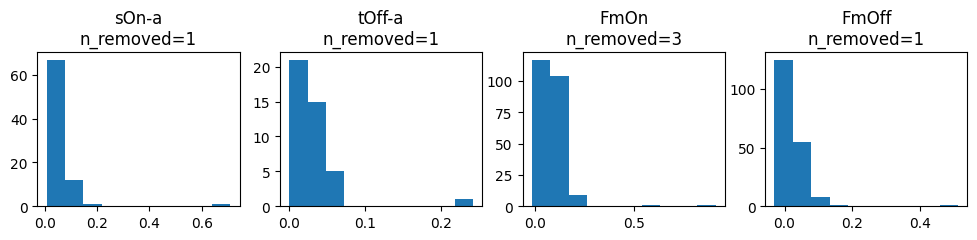

In [21]:
# Some cells still have their axon unlabeled, let's remove them here for the mosaics
df_mosaics = df[df["valid_celltype_final_short"]].copy()
df_mosaics["hull_shape_idx"] = ((df.hull_perimeter + 10) / (df.hull_diameter + 10)) / np.pi - 1

fig, axs = plt.subplots(1, len(celltypes_to_mosaic), figsize=(len(celltypes_to_mosaic)*3, 2))

check_cells = []

for i, ct in enumerate(celltypes_to_mosaic):
    df_ct = df_mosaics[(df_mosaics.celltype_final_short == ct)]

    df_ct_flag = df_ct[df_ct["hull_shape_idx"] > 0.2]
    
    print(ct, list(df_ct_flag.index))
    check_cells += list(df_ct_flag.index)

    ax = axs[i]
    ax.set_title(f"{ct}\nn_removed={len(df_ct_flag)}")
    ax.hist(df_ct.hull_shape_idx)

# Confirm the selection manually before filtering
rm_cells = check_cells
df_mosaics = df_mosaics.loc[~df_mosaics.index.isin(rm_cells)]

# Figures

In [22]:
from eyewire2_morphological_clustering.utils.style import set_rc_params

set_rc_params()

In [23]:
fig_dir = f'../figures/RGC/v{version}'
os.makedirs(fig_dir, exist_ok=True)

## Feature plots

### Dendrograms

In [24]:
from eyewire2_morphological_clustering.utils.dendrogram import ClusterDendrogram

cd = ClusterDendrogram(
    data=emb_feats_norm[df.valid_celltype_final_short & df.include_in_embedding],
    cluster_labels=df.loc[df.valid_celltype_final_short & df.include_in_embedding, "celltype_final_short"],
    feature_names=emb_cols_norm,
)
avg_features = cd.compute_cluster_averages(log_transform=False)
filtered_features, selected_features = cd.filter_features(verbose=False)
dist_matrix = cd.compute_distance_matrix(metric='euclidean')
Z = cd.hierarchical_cluster(method='average')

In [25]:
# import warnings
# from eyewire2_morphological_clustering.utils.dendrogram import PairwiseDiscriminability

# pair_ds = PairwiseDiscriminability(regularization='ledoit_wolf')
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     dend = pair_ds.fit(emb_feats_norm[df.valid_celltype_final_short], df.loc[df.valid_celltype_final_short, "celltype_final_short"])

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage

dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=True,
)

In [27]:
leaf_order = cd.clusters[dendro['leaves']]
leaf_order

array(['vOffOS', 'FmOff', 'On-s-Off-l', 'FmOn', 'UHD', 'HD2', 'HD1',
       'LED', 'tOn-m', 'tOn-s', 'tOff-m', 'tOff-s', 'M5', 'M6', 'OODS',
       'sOff-a', 'sOff-m', 'M1', 'sOn-a', 'tOff-a', 'M2', 'sOnDS',
       'OnOS-s', 'vOnOS-s'], dtype=object)

In [28]:
len(unique_labels)

24

In [29]:
len(leaf_order)

24

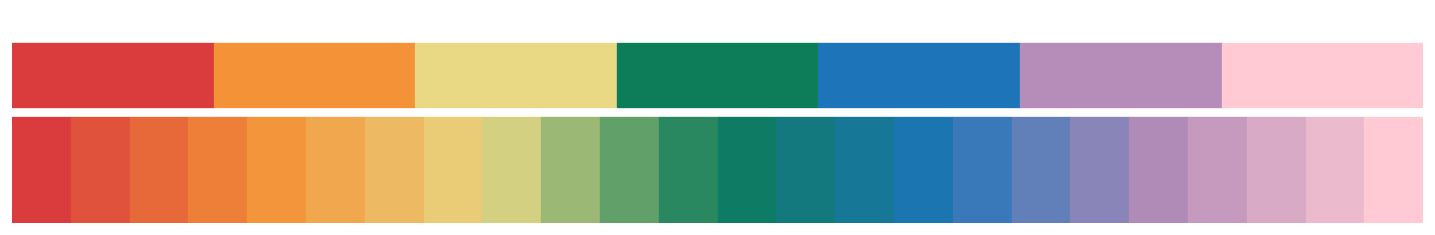

In [30]:
from eyewire2_morphological_clustering.utils import colors

interpolated_colors = colors.interpolate_colors(n=len(unique_labels))
ordered_colors = colors.reorder_colors_for_distinction(interpolated_colors, n_neighbors=4)

label2color = {leaf_name: ordered_colors[i] for i, leaf_name in enumerate(leaf_order)}

### Plot stats

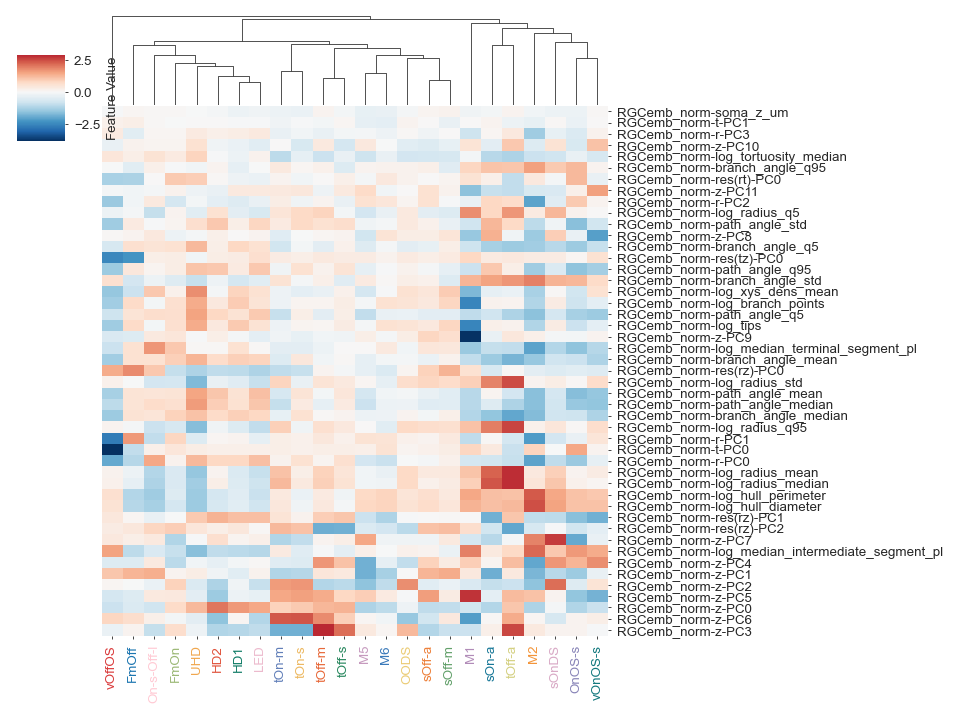

In [31]:
fig = cd.plot_heatmap_with_dendrogram(top_n_features=50, figsize=(8, 6))

ax = fig.ax_heatmap
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

fig.savefig(f'{fig_dir}/rgc-dendrogram_features.svg')
fig.savefig(f'{fig_dir}/rgc-dendrogram_features.png', dpi=600)
plt.show()

### Plot dendrogram

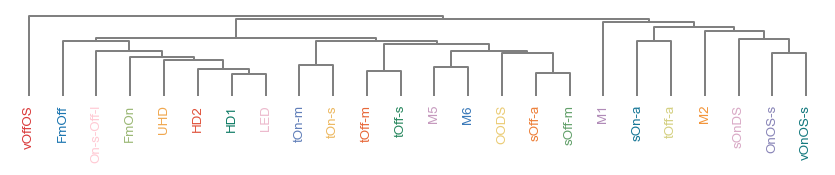

In [32]:
fig, ax = plt.subplots(figsize=(7, 1.5))
sns.despine(left=True, bottom=True, right=True, top=True)

# Plot dendrogram
dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    ax=ax,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=False,
)

ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

assert len(np.unique(xlabelnames)) == len(xlabelnames)

ax.set_yticks([])
plt.tight_layout()

fig.savefig(f'{fig_dir}/rgc-dendrogram.svg')
fig.savefig(f'{fig_dir}/rgc-dendrogram.png', dpi=600)
plt.show()

## TSNE

### Plot

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/embedding.py:229: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


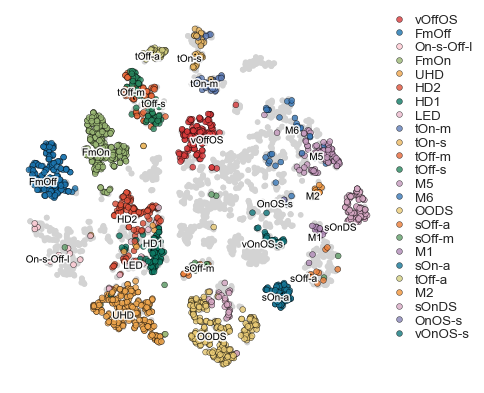

In [33]:
from eyewire2_morphological_clustering.utils.embedding import plot_embedding_v2

plot_embedding_v2(
    df=df[df['include_in_embedding']],
    label2color=label2color,
    fig_path_prefix=f"{fig_dir}/rgc-tsne",
    celltype_col="celltype_final_short",
    plot_order=leaf_order,
    is_labelled_col="valid_celltype_final_short",
    dot_size=12,
    edgecolor="k",
    rasterized=False,
    legend_markerscale=None,
)

### Feature maps

In [34]:
df.rename({"perc_z_095_1": "perc_z_095", "perc_z_005_1": "perc_z_005"}, axis=1, inplace=True)

In [35]:
df["log_soma_rad_um"] = np.log(df["soma_rad_um"])

In [36]:
example_feature_names = [
    'perc_z_005',
    'perc_z_095',

    'log_hull_diameter',
    'log_branch_points',
    
    'log_soma_rad_um',
    'log_radius_mean',
]

example_features = df.loc[:, example_feature_names].values

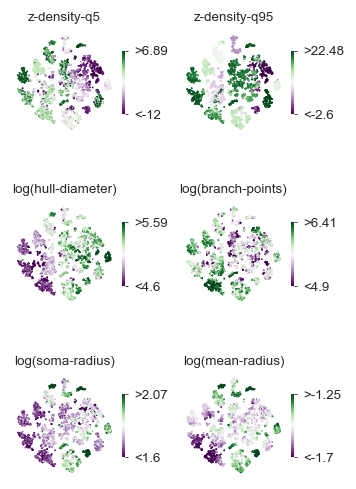

In [37]:
from eyewire2_morphological_clustering.utils.embedding import save_and_plot_feats

fig, axs = save_and_plot_feats(
    all_emb=df.loc[df['include_in_embedding'], ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features[df['include_in_embedding']],
    all_feat_names=example_feature_names, 
    ncols=2,
    fig_dir=fig_dir,
    file_prefix="rgc-tnse-features",
    clip=False,
    stride=1, 
    s=1,
    figsize_per_cell=(1.5, 1.5)
)

## Morph examples

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


0
[720575940572551485, 720575940563523391, 720575940561485291, 720575940551916659, 720575940557716319, 720575940584832054, 720575940562250423, 720575940563564133]


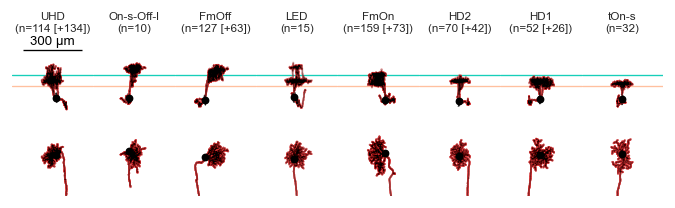

1
[720575940549300948, 720575940568346228, 720575940559773724, 720575940564423249, 720575940559430037, 720575940540499576, 720575940563644533, 720575940554677724]


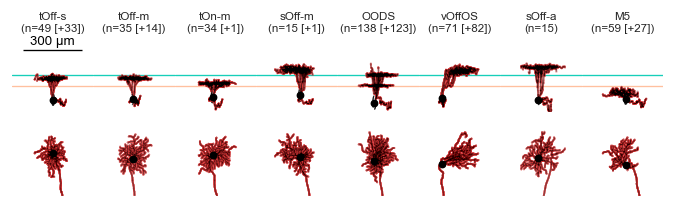

2
[720575940554583314, 720575940557217997, 720575940550011222, 720575940558177239, 720575940562605226, 720575940564572573, 720575940561268174, 720575940568512543]


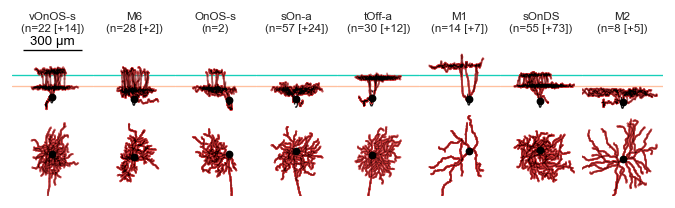

In [38]:
from eyewire2_morphological_clustering.utils.plot_cells import plot_rows

nrows = 3

rad = (all_types_rows.hull_diameter.max() / 2) * 1.1

splits = np.array_split(all_types_rows, nrows)

for i in range(nrows):
    rows = splits[i]

    print(i)
    print(list(rows.index.astype(int)))
    
    fig, axs = plt.subplots(
        2, len(rows), figsize=(7 * rows.shape[0] / splits[0].shape[0], 1.7),
        sharex='all', sharey='row', squeeze=False, height_ratios=(1, 1.2),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]))
    fig.subplots_adjust(wspace=0, hspace=0)
    
    plot_rows(
        rows=rows, rad=rad,
        size=300, fig=fig, axs=axs,
        color=colors.cellclass2color['RGC'],
        show_on_tsne=False, sb_fontsize=8);

    for ax in axs.flat:
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.axis('off')
    
    for j, ax in enumerate(axs[0, :]):
        ct_short = rows.iloc[j].celltype_final_short
        df_ct = df[(df.celltype_final_short==ct_short) & df.valid_celltype_final]
        n_cells = len(df_ct)
        n_cells_clf = sum(df_ct.celltype_final_decision == 'classifier')
        n_cells_label = n_cells - n_cells_clf
        if n_cells_clf > 0:
            ax.set_title(f"{ct_short}\n(n={n_cells_label} [+{n_cells_clf}])", fontsize=7)
        else:
            ax.set_title(f"{ct_short}\n(n={n_cells_label})", fontsize=7)

    fig.savefig(f'{fig_dir}/celltype_final-example_set{i}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype_final-example_set{i}.png', dpi=600, bbox_inches='tight')
    
    plt.show()

## Mosaics

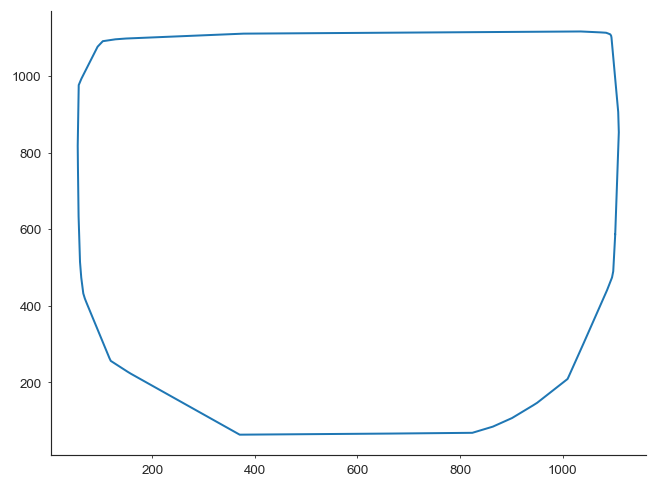

In [39]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

celltype='sOn-a': Found 63 cells and 17 candidates.
celltype='tOff-a': Found 35 cells and 6 candidates.
celltype='FmOn': Found 157 cells and 72 candidates.
celltype='FmOff': Found 129 cells and 60 candidates.


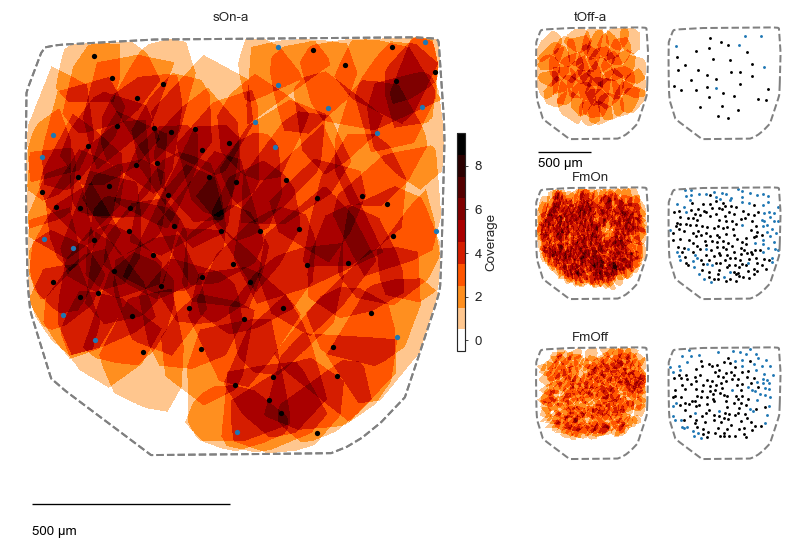

In [40]:
from eyewire2_morphological_clustering.utils.mosaics import plot_multiple_mosaics

extent = [20, 1120, 50, 1150]
max_val = 9

fig, naxs = plt.subplot_mosaic(
    """
    A.Bb
    A.Cc
    A.Dd
    """,
    figsize=(7, 4.1),
    sharex=True,
    sharey=True,
    width_ratios=(3, 0.6, 1, 1),
)

coverage_axs = np.array([naxs['A'], naxs['B'], naxs['C'], naxs['D']])
center_axs = np.array([naxs['A'], naxs['b'], naxs['c'], naxs['d']])
sb_axs = np.array([naxs['A'], naxs['B']])

sns.despine(top=True, right=True, bottom=True, left=True)

ims, c_maxs = plot_multiple_mosaics(
    df=df_mosaics,
    celltype_col='celltype_short',
    candidate_col='celltype_final_short',
    candidate_color='C0',
    celltypes=celltypes_to_mosaic,
    plot_candidate_coverage=True,
    fig=fig,
    coverage_axs=coverage_axs,
    resolutions=[3000, 1000, 1000, 1000],
    center_axs=center_axs,
    title_axs=coverage_axs,
    center_x_col="soma_x_um",
    center_y_col="soma_y_um",
    marker_sizes=[10, 3, 3, 3],
    max_val=max_val,
    extent=extent,
    plot_outlines=False,
    outline_hull=hull_pts,
    cb=False,
    sb_axs=sb_axs,
    sb_size=500,
)

for j, ax in enumerate(coverage_axs):
    ct_short = celltypes_to_mosaic[j]
    ax.set_title(f"{ct_short}", fontsize=8, pad=0)
    
plt.tight_layout(w_pad=-2)

# Custom color bar
for i, celltype_final in enumerate(celltypes_to_mosaic):
    ax = coverage_axs[i]
    im = ims[i]
    c_max = c_maxs[i]
    
    if i > 0:
        if c_max == c_maxs[i-1]:
            continue
    
    pos = ax.get_position()
    
    cax = fig.add_axes([
        pos.x1 + 0.01, # left
        pos.y0 + 0.25 * pos.height,   # bottom (adjust spacing)
        0.01,    
        pos.height * 0.5,
    ])
    
    cbar = fig.colorbar(im, cax=cax, orientation='vertical')
    cbar.set_label('Coverage', fontsize=8, labelpad=2)
    cbar.set_ticks(np.arange(0, c_max + 1, int(np.ceil(c_max/5))))
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_visible(True)

fig.savefig(f'{fig_dir}/rgc-mosaic-{celltypes_to_mosaic}_{extent}.svg', dpi=600, bbox_inches='tight')
fig.savefig(f'{fig_dir}/rgc-mosaic-{celltypes_to_mosaic}_{extent}.png', dpi=600, bbox_inches='tight')

plt.show()

# Website

In [41]:
website_dir = f'../website/v{version}'
os.makedirs(website_dir, exist_ok=True)

In [42]:
website_cols = ['celltype_final', 'celltype_final_short', 'soma_x_um', 'soma_y_um', 'soma_z_um', 'soma_annot_x_um', 'soma_annot_y_um', 'soma_annot_z_um']

## Single examples

In [43]:
xy0 = np.array((48142, 36349)) * 16 / 1000
xy1 = np.array((42035, 31849)) * 16 / 1000
xy2 = np.array((37535, 37956)) * 16 / 1000
xy3 = np.array((43642, 42456)) * 16 / 1000

# Two edge vectors from xy0
edge1 = xy1 - xy0
edge2 = xy3 - xy0

# Points to test
pts = np.column_stack([df.soma_annot_x_um, df.soma_annot_y_um])
rel = pts - xy0  # shape (N, 2)

# Project onto each edge (dot products)
proj1 = rel @ edge1
proj2 = rel @ edge2

# Inside iff projection falls within [0, |edge|^2] for both edges
mask = (
    (proj1 >= 0) & (proj1 <= edge1 @ edge1) &
    (proj2 >= 0) & (proj2 <= edge2 @ edge2)
)

df_in_box = df[mask]

In [44]:
website_rows = []

for celltype_final_short in size_order:
    for df_to_query in [df_in_box, df]:
        rows = df[
            (df.celltype_final_short == celltype_final_short)
            & df.valid_celltype_final_short
        ]
    
        if sum(rows.celltype_final_decision == 'both_strong') > 0:
            rows = rows[rows.celltype_final_decision == 'both_strong']
        
        if len(rows) == 0:
            rows = None
        else:
            break

    if rows is None:
        row = None
    else:
        x = rows['tsne_d0']
        y = rows['tsne_d1']
        
        emb_ct = np.stack([x, y]).T
        
        ct_mean = np.mean(emb_ct, axis=0)
        ct_dists = np.sum((emb_ct - ct_mean) ** 2, axis=1) ** 0.5
        row = rows.iloc[np.argmin(ct_dists)]
        
    website_rows.append(row)
    
df_website_single = pd.DataFrame(website_rows).loc[:, website_cols].copy()
df_website_single.sort_values('celltype_final', inplace=True)
df_website_single.head()

,celltype_final,celltype_final_short,soma_x_um,soma_y_um,soma_z_um,soma_annot_x_um,soma_annot_y_um,soma_annot_z_um
720575940561485291,F-mini-OFF,FmOff,545.011,413.141,-16.3826,545.088,407.440,17.64
720575940557716319,F-mini-ON,FmOn,807.208,862.743,-15.9344,806.944,858.240,17.92
720575940562250423,HD1,HD1,782.990,401.584,-14.3944,781.392,397.904,33.72
720575940584832054,HD2,HD2,736.885,355.544,-17.1205,733.744,349.952,35.84
720575940551916659,Local edge detector,LED,584.128,555.460,-12.4880,582.336,552.064,21.52


In [45]:
df_website_single.to_csv(os.path.join(website_dir, f"RGC_website_single_examples.csv"))

## Mosaics

In [46]:
df_website_mosaic = df_mosaics.loc[df_mosaics.celltype_final_short.isin(celltypes_to_mosaic), website_cols].copy()
df_website_mosaic.sort_values('celltype_final', inplace=True)
df_website_mosaic.head()

,celltype_final,celltype_final_short,soma_x_um,soma_y_um,soma_z_um,soma_annot_x_um,soma_annot_y_um,soma_annot_z_um
cell,,,,,,,,
720575940563008139,F-mini-OFF,FmOff,821.161,532.712,-14.2504,822.496,531.328,27.36
720575940568661514,F-mini-OFF,FmOff,965.840,737.293,-14.2323,965.984,738.000,19.32
720575940568547661,F-mini-OFF,FmOff,265.222,771.629,-13.2643,260.080,769.536,11.24
720575940568512406,F-mini-OFF,FmOff,95.529,560.164,-18.1660,92.512,554.736,46.24
720575940582416254,F-mini-OFF,FmOff,967.141,669.993,-12.4767,966.736,668.624,22.12


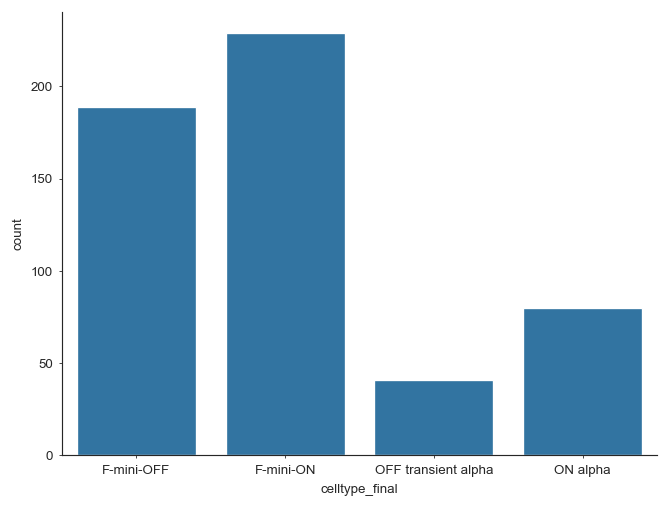

In [47]:
sns.countplot(data=df_website_mosaic, x='celltype_final');

In [48]:
df_website_mosaic.to_csv(os.path.join(website_dir, f"RGC_website_mosaic_examples.csv"))